In [9]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('../Datasets/scrap price.csv')
df=df.dropna()
# sns.pairplot(df)


(205, 1) (205, 1)
[[-0.01126356]
 [ 0.806099  ]]


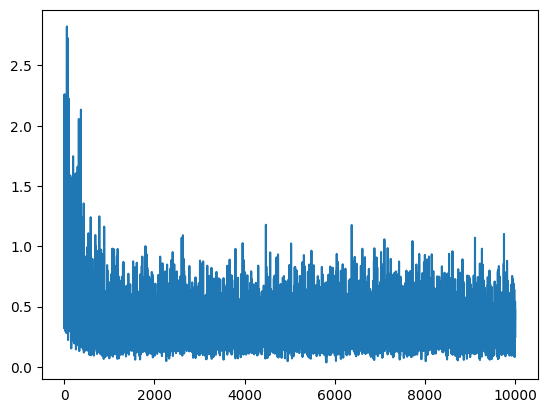

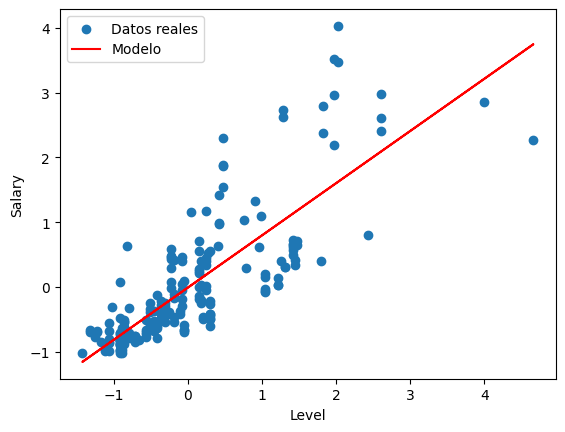

In [10]:
#####################################################################################
############ RMSProp
#####################################################################################

y=df['price'].to_numpy()
x=df[['horsepower']].to_numpy()
y=y[:,None]
print(x.shape,y.shape)
#(205,2) (205,1)

#Z-scot para estandarizar los datos 
m=np.mean(x)
std=np.std(x)
x=(x-m)/std

y_m = np.mean(y)
y_std = np.std(y)
y = (y - y_m) / y_std

#addin bias
matriz_unos=np.ones((len(x),1))
X_bias=np.hstack((matriz_unos,x))  #Elegimos el número de polinomio


#inicializacion

theta=np.zeros((X_bias.shape[1],1))
lr=1e-3
epochs=10000
j_cost_RMS=np.zeros([epochs])
grad_history=np.zeros([epochs, theta.shape[0]])
beta=0.9
v=theta*0
MB = 20
N=len(y)
Theta_RMS=[]
ep=1e-8

#fitting lop 
for i in range(epochs):
    rand_ind = np.random.randint(0,N,MB)

    x_i = X_bias[rand_ind,:].reshape(MB,X_bias.shape[1])
    y_i = y[rand_ind].reshape(MB,1)

    h=np.dot(x_i,theta)
    r=h-y_i
    grad=x_i.T.dot((r))
    v=beta*v+ (1-beta)*(grad**2)    
    
    theta=theta-(lr/(np.sqrt(v)+ep))*grad

    if np.linalg.norm(grad) < ep: #stopping criterion 
        break

    Theta_RMS.append(theta)

    j_cost_RMS[i]=np.mean(np.square(r))
    grad_history[i] = grad.flatten()
    
Theta_RMS=np.array(Theta_RMS)
print(theta)

fig = plt.figure()
plt.plot(j_cost_RMS)
plt.show()


y_pred_RMS = X_bias @ theta

plt.scatter(x, y, label="Datos reales")
plt.plot(x, y_pred_RMS, color='red', label="Modelo")

plt.xlabel("Level")
plt.ylabel("Salary")
plt.legend()

plt.show()

(205, 1) (205, 1)
[[-0.00246878]
 [ 0.81742738]]


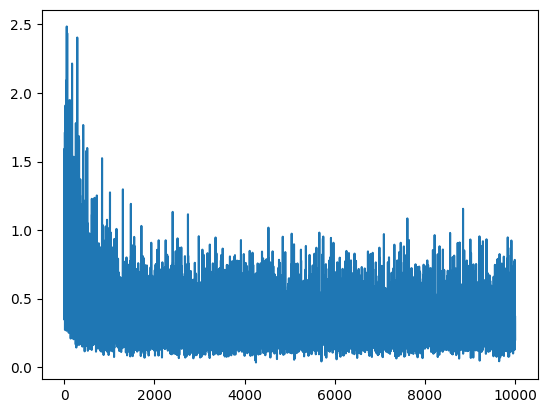

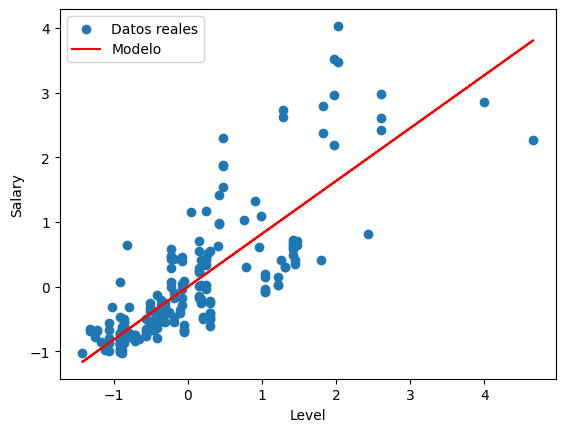

In [11]:
#####################################################################################
############ Adam
#####################################################################################

y=df['price'].to_numpy()
x=df[['horsepower']].to_numpy()
y=y[:,None]
print(x.shape,y.shape)
#(205,2) (205,1)

#Z-scot para estandarizar los datos 
m=np.mean(x)
std=np.std(x)
x=(x-m)/std

y_m = np.mean(y)
y_std = np.std(y)
y = (y - y_m) / y_std

#addin bias
matriz_unos=np.ones((len(x),1))
X_bias=np.hstack((matriz_unos,x))  #Elegimos el número de polinomio


#inicializacion

theta=np.zeros((X_bias.shape[1],1))
lr=1e-3
epochs=10000
j_cost_Adam=np.zeros([epochs])
grad_history=np.zeros([epochs, theta.shape[0]])
beta1=0.9
beta2=0.999
v=theta*0
m=theta*0
MB = 20
N=len(y)
Theta_Adam=[]
ep=1e-8

#fitting lop 
for i in range(epochs):
    
    rand_ind = np.random.randint(0,N,MB)

    x_i = X_bias[rand_ind,:].reshape(MB,X_bias.shape[1])
    y_i = y[rand_ind].reshape(MB,1)

    h=np.dot(x_i,theta)
    r=h-y_i
    grad=x_i.T.dot((r))

    m=beta1*m+ (1-beta1)*grad  #Primer momento
    v=beta2*v+ (1-beta2)*(grad**2)  #Segundo momento

    t = i + 1
    m_corregida=m/(1-beta1**t)
    v_corregida=v/(1-beta2**t)
    
    theta=theta-(lr/(np.sqrt(v_corregida)+ep))*m_corregida

    if np.linalg.norm(grad) < ep: #stopping criterion 
        break

    Theta_Adam.append(theta)

    j_cost_Adam[i]=np.mean(np.square(r))
    grad_history[i] = grad.flatten()
    
Theta_Adam=np.array(Theta_Adam)
print(theta)

fig = plt.figure()
plt.plot(j_cost_Adam)
plt.show()


y_pred_Adam = X_bias @ theta

plt.scatter(x, y, label="Datos reales")
plt.plot(x, y_pred_Adam, color='red', label="Modelo")

plt.xlabel("Level")
plt.ylabel("Salary")
plt.legend()

plt.show()


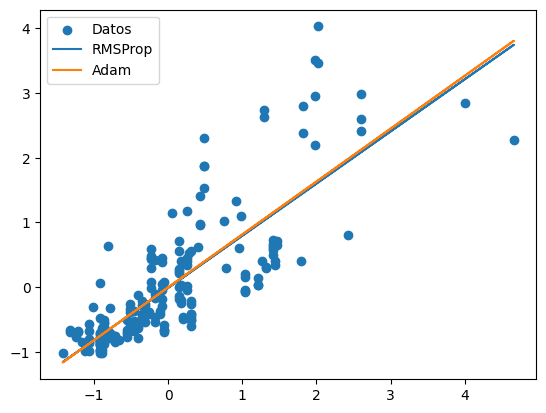

In [12]:
plt.scatter(x, y, label="Datos")

plt.plot(x, y_pred_RMS, label="RMSProp")
plt.plot(x, y_pred_Adam, label="Adam")

plt.legend()
plt.show()

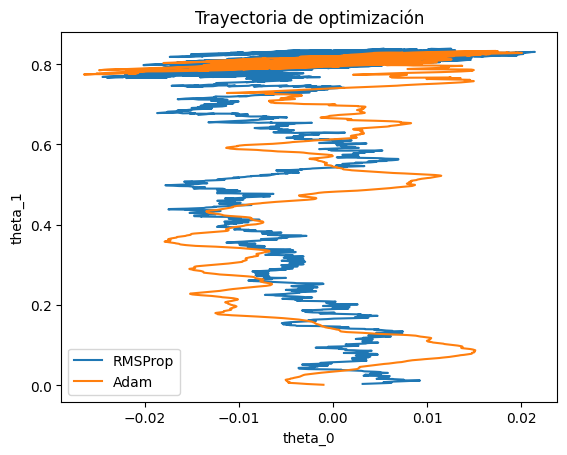

In [13]:
plt.plot(Theta_RMS[:,0], Theta_RMS[:,1], label="RMSProp")
plt.plot(Theta_Adam[:,0], Theta_Adam[:,1], label="Adam")

plt.xlabel("theta_0")
plt.ylabel("theta_1")
plt.title("Trayectoria de optimización")
plt.legend()
plt.show()

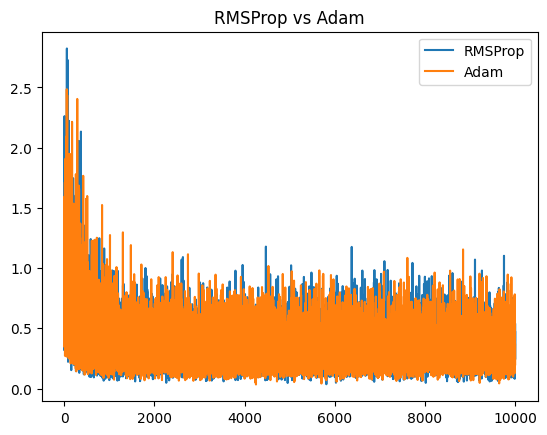

In [14]:
plt.plot(j_cost_RMS, label="RMSProp")
plt.plot(j_cost_Adam, label="Adam")

plt.title("RMSProp vs Adam")
plt.legend()
plt.show()